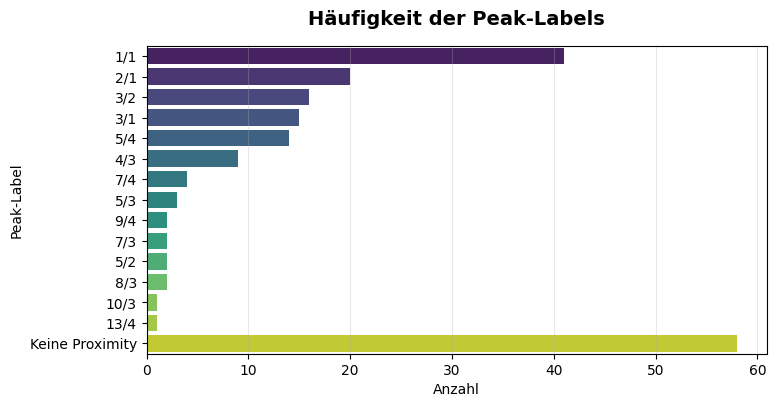

Häufigkeiten der Peak-Labels:
1/1                41
2/1                20
3/2                16
3/1                15
5/4                14
4/3                 9
7/4                 4
5/3                 3
9/4                 2
7/3                 2
5/2                 2
8/3                 2
10/3                1
13/4                1
Keine Proximity    58
dtype: int64


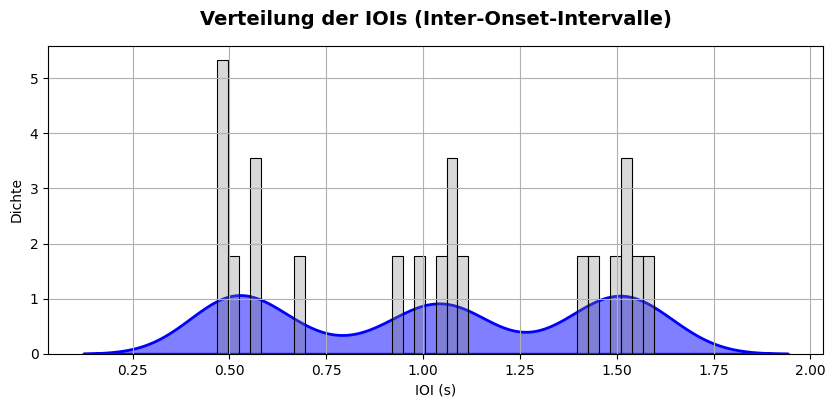

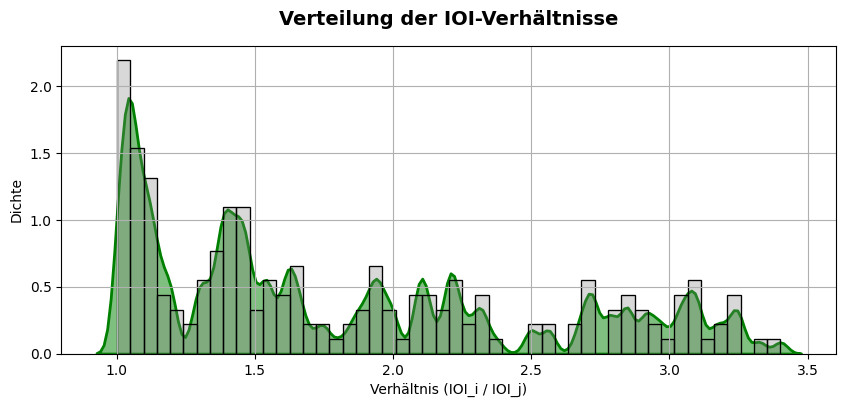

In [ ]:
# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# ===============================================

# =============================
# 0) Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from fractions import Fraction

# =============================
# 1) Proximity-Funktion (Gaussian)
# =============================
def proximity_max_freq_gaussian(
    x,
    sharpness_base=10.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    neighbor_peaks=2,   # wie viele Peaks links+rechts von x getestet werden
    norm_x=1.0,
    output_max=1.0
):
    """
    Optimierte Gaussian-Proximity-Funktion:
    - prüft nur die Ratio-Peaks, die in der Nähe von x liegen (k/f ± neighbor_peaks)
    - x: Skalar oder Array
    - Rückgabe: Array gleicher Form
    """
    x = np.array(x, dtype=float)
    all_freq_values = []

    for f in range(1, max_freq + 1):
        weight = 1.0 / (f ** weight_exponent)
        gauss_max = np.zeros_like(x, dtype=float)

        # nächstliegender Peak-Index zu jedem x
        k_center = np.round(x * f).astype(int)

        for offset in range(-neighbor_peaks, neighbor_peaks + 1):
            k = k_center + offset
            valid = k > 0  # negative oder 0 Peaks sind Unsinn

            if not np.any(valid):
                continue

            mu = k[valid] / f
            sharpness = sharpness_base * (f ** freq_sharpness_exp) * (k[valid] ** sharpness_growth)
            sigma = 1.0 / (sharpness + 1e-9)
            mu_decay = 1.0 / (mu ** decay)

            # Broadcasting über alle validen Peaks
            g = np.exp(-0.5 * ((x[..., None] - mu[None, ...]) / sigma[None, ...]) ** 2)
            contrib = weight * mu_decay * g

            # Max über Peaks in Nachbarschaft
            gauss_max = np.maximum(gauss_max, np.max(contrib, axis=-1))

        all_freq_values.append(gauss_max)

    result = np.maximum.reduce(all_freq_values)

    # Normierung
    max_at_norm_x = np.max([
        (1.0 / (f ** weight_exponent))
        for f in range(1, max_freq + 1)
    ])
    return result / (max_at_norm_x + 1e-9) * output_max

# =============================
# 2) Funktion für IOI-Paare
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max = proximity_max_freq_gaussian(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                # Bestes f und k rekonstruieren
                best_f = None
                best_frac = None
                best_diff = np.inf
                for f in range(1, params["max_freq"] + 1):
                    k = round(r * f)
                    frac = Fraction(k, f).limit_denominator()
                    diff = abs(r - k / f)
                    if diff < best_diff:
                        best_diff = diff
                        best_frac = frac
                        best_f = f
                label = f"{best_frac.numerator}/{best_frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

# =============================
# 3) Parameter, Daten laden & Pairs bauen
# =============================
params = dict(
    sharpness_base=8.0,
    sharpness_growth=1.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    neighbor_peaks=2, 
    norm_x=1.0,
    output_max=1.0
)
PAIR_THRESHOLD = 0.01

filename = "heterochrony-1-3-2_jitter-0050_10.csv"
base_dir = Path("../data/theoretical_sequences/baseIOI-0.50/20beats/")
seq_path = base_dir / filename
if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)

iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

df_pairs, ratios, prox_max = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)

# =============================
# 4) Auswertungen & Visualisierung
# =============================

# --- (a) Häufigkeit der Peak-Labels ---
label_counts = df_pairs["peak_label"].value_counts()
if "Keine Proximity" in label_counts.index:
    keine_count = label_counts["Keine Proximity"]
    label_counts = label_counts.drop("Keine Proximity")
    label_counts = pd.concat([label_counts, pd.Series({"Keine Proximity": keine_count})])

plt.figure(figsize=(8, 4))
sns.barplot(
    x=label_counts.values, 
    y=label_counts.index, 
    hue=label_counts.index, 
    dodge=False, 
    legend=False, 
    palette="viridis"
)
plt.title("Häufigkeit der Peak-Labels", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Anzahl")
plt.ylabel("Peak-Label")
plt.grid(axis="x", alpha=0.3)
plt.show()

print("Häufigkeiten der Peak-Labels:")
print(label_counts)


# --- (b) Verteilung der IOIs ---
plt.figure(figsize=(10, 4))
sns.kdeplot(iois, fill=True, color="blue", alpha=0.5, lw=2, bw_adjust=0.5)
sns.histplot(iois, bins=40, color="gray", alpha=0.3, stat="density")
plt.title("Verteilung der IOIs (Inter-Onset-Intervalle)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("IOI (s)")
plt.ylabel("Dichte")
plt.grid(True)
plt.show()


# --- (c) Verteilung der IOI-Verhältnisse ---
plt.figure(figsize=(10, 4))
sns.kdeplot(df_pairs["ratio"], fill=True, color="green", alpha=0.5, lw=2, bw_adjust=0.1)
sns.histplot(df_pairs["ratio"], bins=50, color="gray", alpha=0.3, stat="density")
plt.title("Verteilung der IOI-Verhältnisse", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Verhältnis (IOI_i / IOI_j)")
plt.ylabel("Dichte")
plt.grid(True)
plt.show()

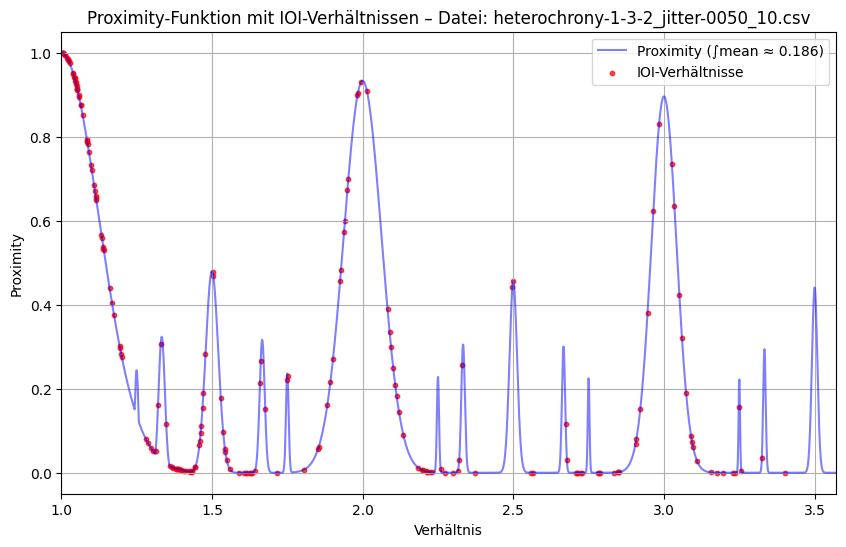

In [17]:
# === 1) Proximity-Funktion + Punkte ===
plt.figure(figsize=(10, 6))

# Dynamische Grenzen aus den Daten bestimmen
x_min = max(1.0, df_pairs["ratio"].min() * 0.95)  # kleiner Puffer nach unten
x_max = df_pairs["ratio"].max() * 1.05            # Puffer nach oben

# Blaue Kurve über den ganzen Plotbereich
x_range = np.linspace(x_min, x_max, 2000)
y_curve = np.array([proximity_max_freq_gaussian(x, **params)[0] for x in x_range])

# Mittelwert für diesen Bereich
mean_prox = simpson(y_curve, x=x_range) / (x_range[-1] - x_range[0])

# Plotten
plt.plot(
    x_range,
    y_curve,
    label=f"Proximity (∫mean ≈ {mean_prox:.3f})",
    alpha=0.5,
    color="blue"
)
plt.scatter(df_pairs["ratio"].values, df_pairs["proximity"].values, 
            s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")

plt.title(f"Proximity-Funktion mit IOI-Verhältnissen – Datei: {filename}")
plt.xlabel("Verhältnis")
plt.ylabel("Proximity")
plt.xlim(x_min, x_max)
plt.legend()
plt.grid(True)
plt.show()


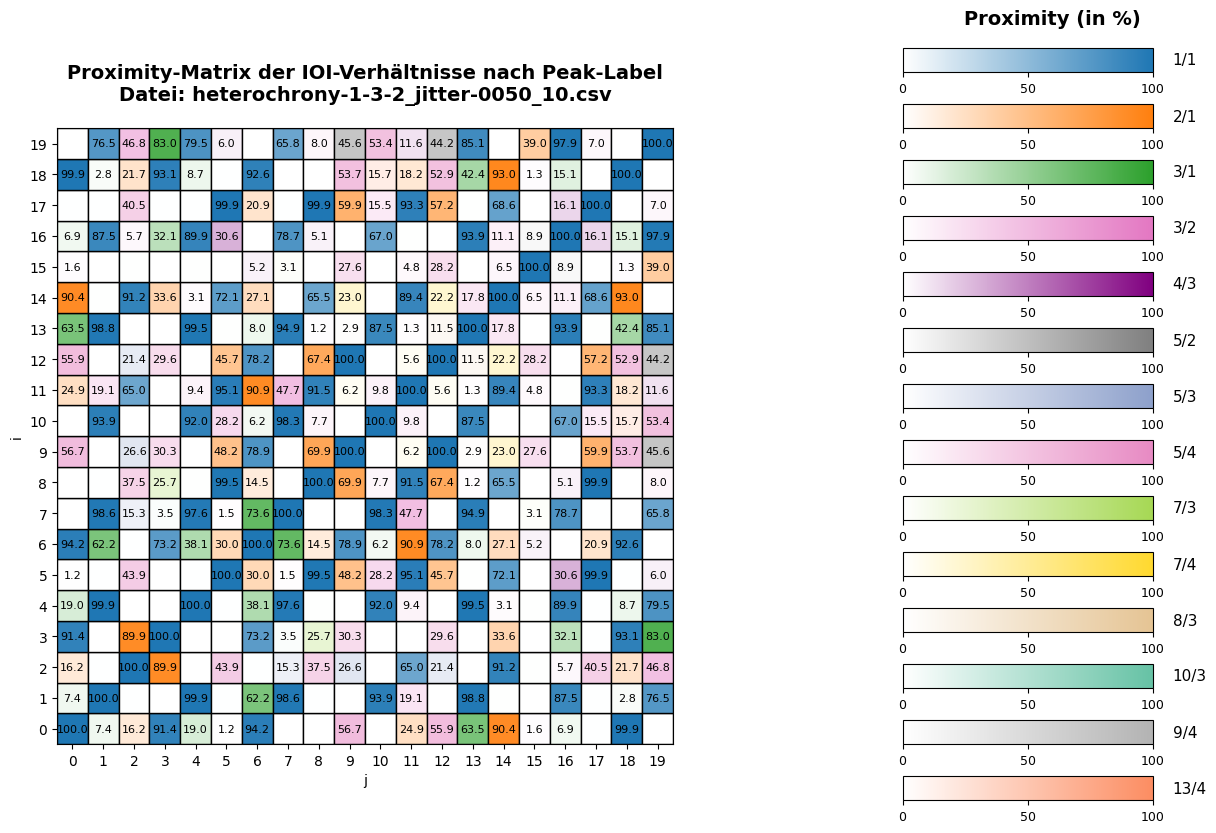

In [13]:
# === 2) Recurrence-Plot (Peak-Label-Farbskalen) ===

records = []
n = len(iois)
for i in range(n):
    for j in range(n):
        ratio = max(iois[i], iois[j]) / min(iois[i], iois[j])
        prox_val = proximity_max_freq_gaussian([ratio], **params)[0]
        if prox_val > PAIR_THRESHOLD:
            frac = Fraction(ratio).limit_denominator(params["max_freq"])
            peak_label = f"{frac.numerator}/{frac.denominator}"
        else:
            peak_label = "Keine Proximity"
        records.append({
            "i": i,
            "j": j,
            "ioi_i": iois[i],
            "ioi_j": iois[j],
            "ratio": ratio,
            "prox_value": prox_val,
            "peak_label": peak_label
        })

all_pairs_df = pd.DataFrame.from_records(records)

# === Pivot-Tabellen ===
pivot_vals = all_pairs_df.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = all_pairs_df.pivot(index="i", columns="j", values="peak_label")

# === Farbdefinition ===
unique_labels = sorted(set(all_pairs_df["peak_label"]))

tab10 = plt.cm.tab10.colors  
fixed_colors = {
    "1/1": tab10[0],  # blau
    "2/1": tab10[1],  # orange
    "3/1": tab10[2],  # grün
    "4/1": tab10[3],  # rot
    "5/1": tab10[4],  # lila
    "1/2": tab10[5],  # braun
    "3/2": tab10[6],  # pink
    "5/2": tab10[7],  # grau
    "1/3": tab10[8],  # olivgrün
    "2/3": tab10[9],  # hellblau
    "4/3": (0.5, 0.0, 0.5)  # extra dunkelviolett
}

label_to_cmap = {}
# feste Farben
for label, color in fixed_colors.items():
    if label in unique_labels:
        cmap_colors = [(1,1,1), plt.cm.colors.to_rgb(color)]
        label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# Rest mit Set2
remaining_labels = [lab for lab in unique_labels if lab not in label_to_cmap]
palette = sns.color_palette("Set2", len(remaining_labels))
for label, base_color in zip(remaining_labels, palette):
    cmap_colors = [(1,1,1), base_color]
    label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# === Plot zeichnen ===
fig, ax = plt.subplots(figsize=(10, 8))

for (i, j), val in np.ndenumerate(pivot_vals.values):
    label = pivot_labels.iloc[i, j]
    cmap = label_to_cmap[label]

    if np.isnan(val):
        color = (1, 1, 1, 1)  # weiß
    else:
        color = cmap(val / 100)

    rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor="black")
    ax.add_patch(rect)

    # Zahlenwerte nur, wenn Matrix klein genug
    if n <= 20 and not np.isnan(val) and label != "Keine Proximity":
        # sauber in einen Skalar umwandeln
        val_float = val.item() if isinstance(val, np.ndarray) else float(val)
        ax.text(
            j + 0.5, i + 0.5, f"{val_float:.1f}",
            ha='center', va='center', fontsize=8, color="black"
        )

# Achsen einstellen
ax.set_xlim(0, n)
ax.set_ylim(0, n)
ax.set_aspect("equal")
ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_xticklabels(range(n))
ax.set_yticklabels(range(n))
ax.set_xlabel("j")
ax.set_ylabel("i")

# Titel mit mehr Abstand
ax.set_title(f"Proximity-Matrix der IOI-Verhältnisse nach Peak-Label\nDatei: {filename}",
             fontweight="bold", fontsize=14, pad=20)

# === Legende ===
legend_labels = [lab for lab in unique_labels if lab != "Keine Proximity"]

# nach Zähler+Nenner sortieren
def frac_complexity(label):
    try:
        num, den = map(int, label.split("/"))
        return num + den
    except:
        return float("inf")  # falls kein Bruch
legend_labels = sorted(legend_labels, key=frac_complexity)

legend_x_start = 1.05
legend_y_start = 0.95
cbar_height = 0.03
spacing = 0.04

fig.text(legend_x_start + 0.15, legend_y_start + 0.06,
         "Proximity (in %)", ha="center", fontsize=14, fontweight="bold")

for idx, label in enumerate(legend_labels):
    cmap = label_to_cmap[label]
    norm = plt.Normalize(vmin=0, vmax=100)
    y_pos = legend_y_start - idx * (cbar_height + spacing)

    cbar_ax = fig.add_axes([legend_x_start, y_pos, 0.25, cbar_height])
    cb = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=cbar_ax, orientation="horizontal"
    )
    cb.set_ticks([0, 50, 100])
    cb.ax.tick_params(labelsize=9)

    fig.text(legend_x_start + 0.27, y_pos + cbar_height / 2,
             label, va="center", fontsize=11)

plt.show()


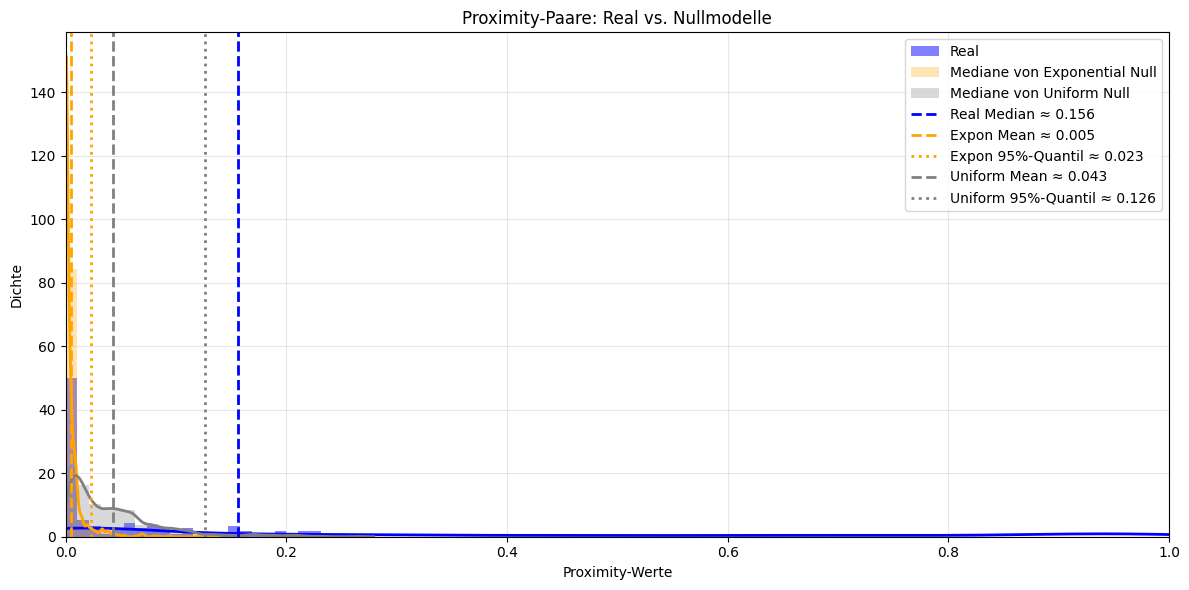


=== Ergebnisse ===
median_real: 0.1558
median_expon: 0.0052
std_expon: 0.0110
zscore_expon: 13.6232
pval_expon: 0.0010
median_uniform: 0.0428
std_uniform: 0.0424
zscore_uniform: 2.6642
pval_uniform: 0.0340
quant95_expon: 0.0232
quant95_uniform: 0.1259


In [14]:
# === 3) Kombiniertes Histogramm mit Anteilen + 95%-Quantil ===
def analyze_single_sequence(iois, params, num_sequences=1000, seed=42, bins=50, plot_kde=True):
    """
    Analysiert eine einzelne IOI-Sequenz gegen zwei Nullmodelle (Exponential, Uniform)
    und erstellt Histogramm mit Mean, 95%-Quantilen, Z-Score und p-Wert.
    
    Rückgabe: dict mit realen Proximity-Paaren, Nullmodellen und Statistik.
    """
    rng = np.random.default_rng(seed)
    sequence_length = len(iois)
    max_ioi = float(np.max(iois))
    mean_ioi = float(np.mean(iois))
    
    # -----------------------------
    # Reale Proximity-Paare
    # -----------------------------
    ratios_real = np.array([[max(iois[i], iois[j])/min(iois[i], iois[j]) 
                             for j in range(sequence_length)] for i in range(sequence_length)])
    prox_mat_real = proximity_max_freq_gaussian(ratios_real, **params)
    triu_idx = np.triu_indices_from(prox_mat_real, k=1)
    proximity_real = prox_mat_real[triu_idx]
    median_real = np.median(proximity_real)
    
    # -----------------------------
    # Nullmodell: Exponential
    # -----------------------------
    medians_expon = []
    proximity_expon_all = []
    for _ in range(num_sequences):
        sim_iois = rng.exponential(scale=mean_ioi, size=sequence_length)
        ratios = np.array([[max(sim_iois[i], sim_iois[j])/min(sim_iois[i], sim_iois[j]) 
                            for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat = proximity_max_freq_gaussian(ratios, **params)
        vals = prox_mat[triu_idx]
        proximity_expon_all.append(vals)
        medians_expon.append(np.median(vals))
    proximity_expon_all = np.concatenate(proximity_expon_all)
    median_expon = np.mean(medians_expon)
    std_expon = np.std(medians_expon, ddof=1)
    zscore_expon = (median_real - median_expon) / (std_expon + 1e-12)
    pval_expon = (np.sum(np.array(medians_expon) >= median_real) + 1) / (num_sequences + 1)
    quant95_expon = np.percentile(medians_expon, 95)
    
    # -----------------------------
    # Nullmodell: Uniform
    # -----------------------------
    medians_uniform = []
    proximity_uniform_all = []
    for _ in range(num_sequences):
        sim_iois = rng.uniform(0.01, max_ioi, size=sequence_length)
        ratios = np.array([[max(sim_iois[i], sim_iois[j])/min(sim_iois[i], sim_iois[j]) 
                            for j in range(sequence_length)] for i in range(sequence_length)])
        prox_mat = proximity_max_freq_gaussian(ratios, **params)
        vals = prox_mat[triu_idx]
        proximity_uniform_all.append(vals)
        medians_uniform.append(np.median(vals))
    proximity_uniform_all = np.concatenate(proximity_uniform_all)
    median_uniform = np.mean(medians_uniform)
    std_uniform = np.std(medians_uniform, ddof=1)
    zscore_uniform = (median_real - median_uniform) / std_uniform if std_uniform > 0 else np.nan
    pval_uniform = (np.sum(np.array(medians_uniform) >= median_real) + 1) / (num_sequences + 1)
    quant95_uniform = np.percentile(medians_uniform, 95)
    
    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(12,6))
    colors = {"Real": "blue", "Expon": "orange", "Uniform": "gray"}
    
    # Gemeinsamer Wertebereich über beide Nullmodelle
    all_nulls = np.concatenate([medians_expon, medians_uniform])
    bin_edges = np.linspace(np.min(all_nulls), np.max(all_nulls), bins+1)

    plt.hist(proximity_real, bins=bin_edges, density=True, alpha=0.5, color=colors["Real"], label="Real")
    plt.hist(medians_expon, bins=bin_edges, density=True, alpha=0.3, color=colors["Expon"], label="Mediane von Exponential Null")
    plt.hist(medians_uniform, bins=bin_edges, density=True, alpha=0.3, color=colors["Uniform"], label="Mediane von Uniform Null")
    
    if plot_kde:
        sns.kdeplot(proximity_real, bw_adjust=0.5, color=colors["Real"], linewidth=2)
        sns.kdeplot(medians_expon, bw_adjust=0.5, color=colors["Expon"], linewidth=2)
        sns.kdeplot(medians_uniform, bw_adjust=0.5, color=colors["Uniform"], linewidth=2)
    
    # Mittelwerte & 95%-Quantile
    plt.axvline(median_real, color=colors["Real"], linestyle="--", linewidth=2, label=f"Real Median ≈ {median_real:.3f}")
    plt.axvline(median_expon, color=colors["Expon"], linestyle="--", linewidth=2, label=f"Expon Mean ≈ {median_expon:.3f}")
    plt.axvline(quant95_expon, color=colors["Expon"], linestyle=":", linewidth=2, label=f"Expon 95%-Quantil ≈ {quant95_expon:.3f}")
    plt.axvline(median_uniform, color=colors["Uniform"], linestyle="--", linewidth=2, label=f"Uniform Mean ≈ {median_uniform:.3f}")
    plt.axvline(quant95_uniform, color=colors["Uniform"], linestyle=":", linewidth=2, label=f"Uniform 95%-Quantil ≈ {quant95_uniform:.3f}")
    
    plt.xlabel("Proximity-Werte")
    plt.ylabel("Dichte")
    plt.title("Proximity-Paare: Real vs. Nullmodelle")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()
    
    # -----------------------------
    # Ergebnisse zurückgeben
    # -----------------------------
    results = {
        "median_real": median_real,
        "median_expon": median_expon,
        "std_expon": std_expon,
        "zscore_expon": zscore_expon,
        "pval_expon": pval_expon,
        "median_uniform": median_uniform,
        "std_uniform": std_uniform,
        "zscore_uniform": zscore_uniform,
        "pval_uniform": pval_uniform,
        "quant95_expon": quant95_expon,
        "quant95_uniform": quant95_uniform,
    }
    print("\n=== Ergebnisse ===")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")
        
    return {
        "proximity_real": proximity_real,
        "proximity_expon_all": proximity_expon_all,
        "proximity_uniform_all": proximity_uniform_all,
        "results": results
    }

results = analyze_single_sequence(iois, params, num_sequences=1000, seed=42, bins=25, plot_kde=True)

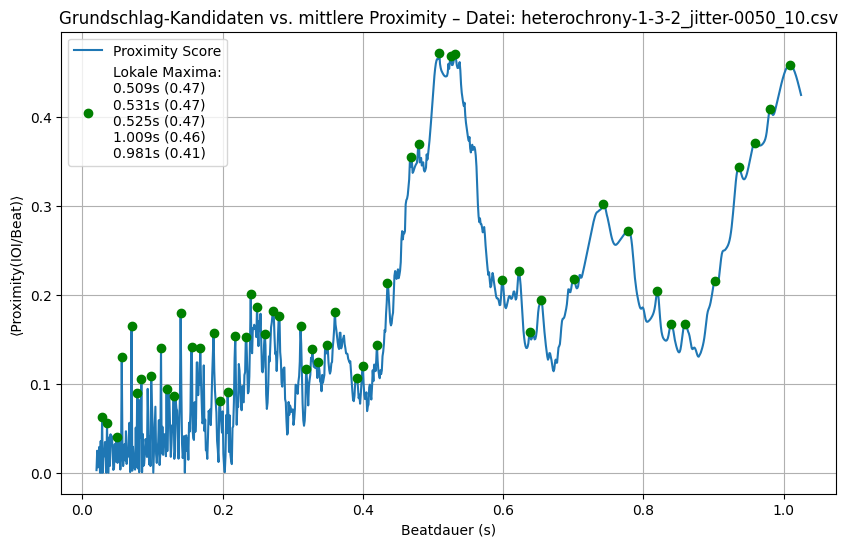

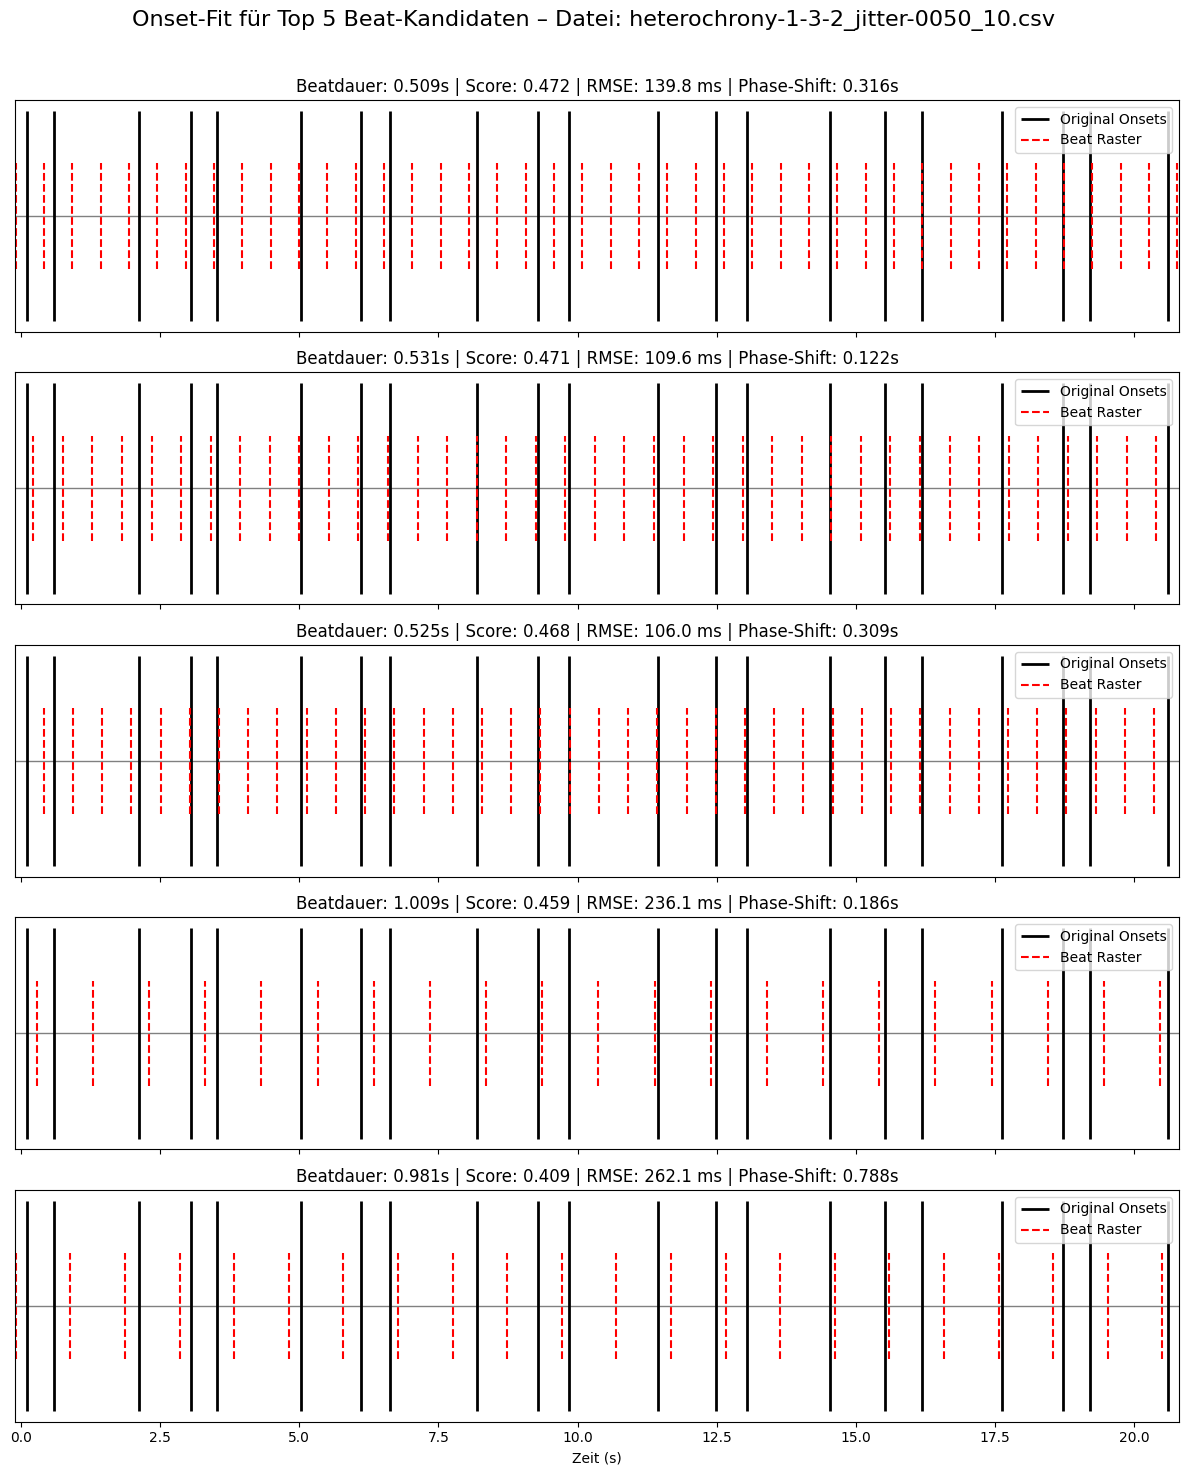

In [15]:
# === 4) Beatfinding via Kandidaten und lokalen Maxima ===

from scipy.signal import argrelextrema

# =============================
# 2) Hilfsfunktionen
# =============================
def round_to_resolution(x, resolution):
    return round(x / resolution) * resolution

def generate_beat_candidates_from_iois(iois, resolution=0.001, max_denominator=24):
    if len(iois) == 0:
        return []

    max_ioi = float(np.max(iois))
    min_ioi = float(np.min(iois)) / max_denominator  # dynamisches min_ioi

    raster = np.arange(min_ioi, max_ioi + resolution/2, resolution)
    candidates = set(round_to_resolution(val, resolution) for val in raster)

    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(round_to_resolution(beat, resolution))

    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(round_to_resolution(val, resolution))

    # === Filter: Kandidaten müssen mindestens so viele Beats abdecken wie IOIs existieren ===
    duration = float(np.sum(iois))
    n_iois = len(iois)
    filtered_candidates = []
    for beat in sorted(candidates):
        if beat <= 0:  # ❌ Filter für 0 und negative Beats
            continue
        n_beats = int(duration // beat)
        if n_beats >= n_iois:
            filtered_candidates.append(beat)

    return filtered_candidates

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals = proximity_max_freq_gaussian(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=2):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

# =============================
# 7) Beat-Kandidaten
# =============================
beat_candidates = generate_beat_candidates_from_iois(iois)
scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
local_maxima = find_local_maxima(beat_candidates, scores, order=5)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# === 4) Beat-Kandidaten & Score ===
plt.figure(figsize=(10, 6))
plt.plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    plt.plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.3f}s ({score:.2f})" for beat, score in local_maxima_top5]
plt.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
plt.title(f"Grundschlag-Kandidaten vs. mittlere Proximity – Datei: {filename}")
plt.xlabel("Beatdauer (s)")
plt.ylabel("⟨Proximity(IOI/Beat)⟩")
plt.legend()
plt.grid(True)
plt.show()

# =============================
# 8) Top-5 Onset-Fit
# =============================

def compute_beat_rmse(onsets, beat_period, resolution=0.001):
    """
    Berechnet den besten Phasen-Shift für die Beats, basierend auf RMSE.
    
    Parameters:
        onsets (array-like): Zeitpunkte der Onsets
        beat_period (float): vermutete Beatdauer
        resolution (float): Schrittweite für Phasen-Shift-Suche
    
    Returns:
        best_shift (float): Shift, der RMSE minimiert
        best_rmse (float): Minimaler RMSE-Wert
        best_beats (np.array): Beat-Zeiten mit optimalem Shift
    """
    onsets = np.array(onsets)
    first_onset = onsets[0]
    last_onset = onsets[-1]
    
    search_range = np.arange(0, beat_period, resolution)
    best_shift = 0.0
    best_rmse = float('inf')
    best_beats = None

    for shift in search_range:
        # Beat-Zeiten, einen Beat davor und einen danach erweitern
        start_beat = first_onset - beat_period + shift
        end_beat = last_onset + beat_period
        beats = np.arange(start_beat, end_beat + resolution, beat_period)

        # Für jeden Onset den nächsten Beat suchen
        nearest_beats = beats[np.argmin(np.abs(onsets[:, None] - beats[None, :]), axis=1)]

        # RMSE berechnen
        rmse = np.sqrt(((onsets - nearest_beats)**2).mean())

        if rmse < best_rmse:
            best_rmse = rmse
            best_shift = shift
            best_beats = beats

    return best_shift, best_rmse, best_beats

n_top = len(local_maxima_top5)
if n_top > 0:
    fig2, axes2 = plt.subplots(n_top, 1, figsize=(12, 3 * n_top), sharex=True)
    fig2.suptitle(f"Onset-Fit für Top {n_top} Beat-Kandidaten – Datei: {filename}", fontsize=16)
    if n_top == 1:
        axes2 = [axes2]
    for idx, (beat, score) in enumerate(local_maxima_top5):
        ax = axes2[idx]
        best_shift, best_rmse, best_beats = compute_beat_rmse(onsets, beat)
        ax.axhline(0, color='gray', linewidth=1)
        ax.vlines(onsets, -0.2, 0.2, color='black', linewidth=2, label='Original Onsets')
        ax.vlines(best_beats, -0.1, 0.1, color='red', linestyle='--', label='Beat Raster')
        title = (f"Beatdauer: {beat:.3f}s | Score: {score:.3f} | "
        f"RMSE: {best_rmse*1000:.1f} ms | Phase-Shift: {best_shift:.3f}s")
        ax.set_title(title)
        ax.set_yticks([])
        ax.set_xlim(onsets[0] - 0.2, onsets[-1] + 0.2)
        ax.legend(loc='upper right')
    plt.xlabel("Zeit (s)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()
else:
    print("\nKeine lokalen Maxima gefunden — überspringe Onset-Fit Visualisierung.")